This folder is sandboxed from the rest of the emulator, intended to test final emulator predictions using exact parameters.

In [1]:
saved_seds = []

In [2]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

from tardis.io.configuration.config_reader import Configuration
from tardis.simulation import Simulation
from tardis.io.atom_data.base import AtomData
from grid_run.make_csvy import make_csvy, make_abundances
import astropy.units as u

os.environ['OMP_NUM_THREADS'] = '4'
os.environ['MKL_NUM_THREADS'] = '4'
os.environ['NUMEXPR_NUM_THREADS'] = '4'

sandbox_dir = os.path.abspath('.')
v_start = 5879.888876 * u.km/u.s
X = 0.7
Z = 0.02

# Run simulation
make_csvy(
    v_start,
    v_stop = v_start * 3,
    shells = 10,
    csvy_path=os.path.join(sandbox_dir, 'model.csvy'),
    abundances=make_abundances(X, Z)
)
atomic = AtomData.from_hdf(os.path.join(sandbox_dir, 'atom_data.h5'))
config = Configuration.from_yaml(os.path.join(sandbox_dir, 'config.yml'))

sim = Simulation.from_config(
    config,
    atom_data = atomic,
    virtual_packet_logging=False,
    show_convergence_plots=False,
    export_convergence_plots=False,
    log_level='DEBUG'
)
sim.run_convergence()
sim.run_final()

Iterations:          0/? [00:00<?, ?it/s]

Packets:             0/? [00:00<?, ?it/s]

Zeta_data missing - replaced with 1s. Missing ions: [(12, 13), (14, 15), (16, 17), (26, 27)]
Zeta_data missing - replaced with 1s. Missing ions: [(12, 13), (14, 15), (16, 17), (26, 27)]
/home/mikel/GitHub/tardis/tardis/transport/montecarlo/montecarlo_main_loop.py:123: NumbaTypeSafetyWarning:

unsafe cast from uint64 to int64. Precision may be lost.



TqdmHBox(children=(HTML(value='Iterations:', layout=Layout(width='6%')), FloatProgress(value=0.0, layout=Layou…

TqdmHBox(children=(HTML(value='Packets:\u2007\u2007\u2007', layout=Layout(width='6%')), FloatProgress(value=0.…

In [ ]:
#print(sim.plasma.plasma_properties_dict.keys())
print(sim.plasma.dilute_planckian_radiation_field.temperature_kelvin)
print(sim.converged)
print(sim.iterations_executed)
print(sim.iterations_t_inner)

In [3]:
y_mod = sim.spectrum_solver.spectrum_virtual_packets.luminosity_density_lambda.value
saved_seds.append(y_mod)

-3.1097290093284755
-0.5717552472251555


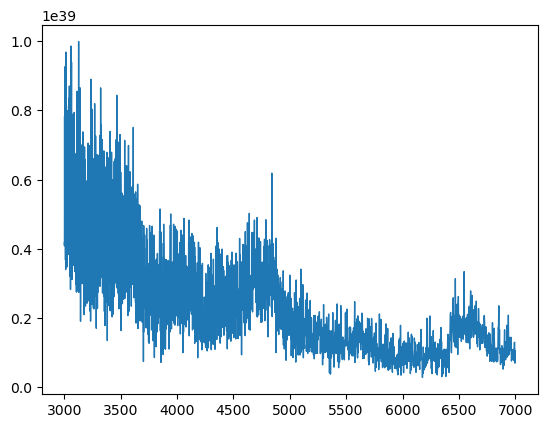

In [3]:
import matplotlib.pyplot as plt

wav = sim.spectrum_solver.spectrum_virtual_packets.wavelength.value
flux = sim.spectrum_solver.spectrum_virtual_packets.luminosity_density_lambda.value

print(wav[1] - wav[0])
print(wav[-1] - wav[-2])
plt.plot(wav, flux, lw=1)
plt.show()

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

wav = sim.spectrum_solver.spectrum_virtual_packets.wavelength.value

# Get observed data
from scipy.interpolate import interp1d
obs_df = pd.read_csv('/home/mikel/GitHub/iip-emulator/interpolator/2020jfo-FLOYDS-S-2020-05-19.csv', comment='#')
y_obs = interp1d(obs_df['wavelength'], obs_df['flux'], bounds_error=False)(wav)

# Flux calibrate
from astropy.constants import c
filter_df = pd.read_csv('/home/mikel/GitHub/iip-emulator/interpolator/Palomar_ZTF.r_fil.dat', names=['wavelength', 'transmission'], sep=' ')
transmission = interp1d(filter_df['wavelength'], filter_df['transmission'], bounds_error=False)(wav)
m_AB = 14.547
f_0 = 2.64009e-9 * u.erg/u.cm**2/u.s/u.AA
f_density = 10**(m_AB/-2.5) * f_0
mask = np.isfinite(transmission)
y_obs *= np.sum(f_density.value*transmission[mask]) / np.sum(y_obs[mask])

mask = ~np.isnan(y_obs)
wav = wav[mask]
y_obs = y_obs[mask]

for y_mod in saved_seds:
    y_mod = y_mod[mask]

    # Find best fit scale
    def f(x):
        scale = x[0]
        y1 = y_mod
        y2 = y_obs*scale
        fe = np.abs(y1 - y2)/y2
        mean_fe = np.mean(fe)
        mse = np.mean((y1-y2)**2)
        return mse

    from scipy.optimize import differential_evolution
    scale_guess = np.max(y_mod) / np.max(y_obs)
    result = differential_evolution(f, x0=[scale_guess], bounds=[(10**50, 10**60)])
    scale = result.x[0]
    distance = np.sqrt(scale/4/np.pi) * u.cm
    print('scale guess:', scale_guess)
    print('scale:', scale)
    print('distance:', distance.to(u.Mpc))

    plt.plot(wav, y_mod, label='model')
    plt.plot(wav, y_obs*scale, label='observed')
    plt.legend()
    plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/home/mikel/GitHub/iip-emulator/interpolator/2020jfo-FLOYDS-S-2020-05-19.csv'